X shape : (112002, 30, 4)
y shape : (112002,)
Nb classes : 25
Train shape : (89601, 30, 4)
Test shape  : (22401, 30, 4)
Exemple de poids de classes : [(0, 22.26111801242236), (1, 2.4414441416893733), (2, 0.5310475626018669), (3, 6.686641791044776), (4, 4.594923076923077)]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,449 (91.60 KB)

 Trainable params: 23,449 (91.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.1554 - loss: 2.8856 - val_accuracy: 0.2852 - val_loss: 2.4761
Epoch 2/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.2611 - loss: 2.5183 - val_accuracy: 0.3317 - val_loss: 2.2871
Epoch 3/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.2861 - loss: 2.3948 - val_accuracy: 0.3158 - val_loss: 2.2618
Epoch 4/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.2892 - loss: 2.3227 - val_accuracy: 0.3230 - val_loss: 2.1999
Epoch 5/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.3088 - loss: 2.2686 - val_accuracy: 0.3486 - val_loss: 2.1189
Epoch 6/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.3175 - loss: 2.2242 - val_accuracy: 0.3552 - val_loss: 2.0741
Epoch 7/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.3271 - loss: 2.1757 - val_accuracy: 0.3533 - val_loss: 2.0814
Epoch 8/40
560/560 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.3310 - loss: 2.1487 - 

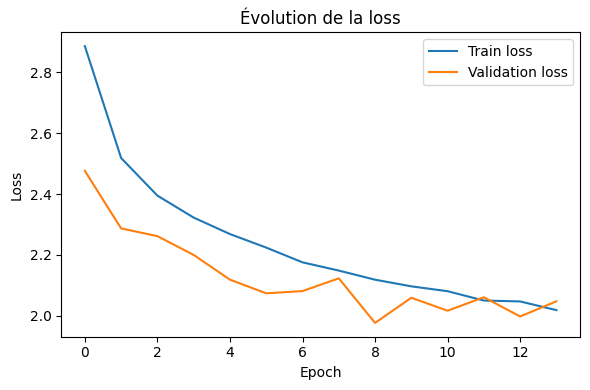

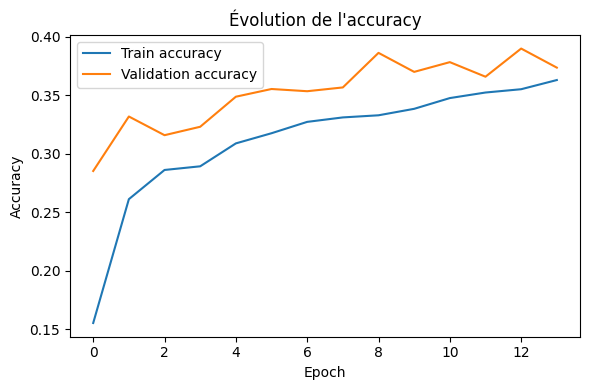

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. Configuration
# =========================
DATADIR = Path("lstm_data")
RANDOM_STATE = 42
TEST_SIZE = 0.2
BATCH_SIZE = 128
EPOCHS = 40

# Pour reproductibilité
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# =========================
# 2. Chargement des données
# =========================
X = np.load("X_lstm.npy")
y = np.load( "y_lstm.npy")
class_names = pd.read_csv("classes_lstm.csv")["class"].astype(str).values

print("X shape :", X.shape)
print("y shape :", y.shape)
print("Nb classes :", len(class_names))

# =========================
# 3. Standardisation
# =========================
mean = X.mean(axis=(0, 1), keepdims=True)
std = X.std(axis=(0, 1), keepdims=True) + 1e-6
X = (X - mean) / std

# =========================
# 4. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)

# =========================
# 5. Poids de classes
# =========================
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

print("Exemple de poids de classes :", list(class_weight_dict.items())[:5])

# =========================
# 6. Construction du modèle
# =========================
n_dates = X.shape[1]
n_features = X.shape[2]
n_classes = len(np.unique(y))

model = Sequential([
    Masking(mask_value=0.0, input_shape=(n_dates, n_features)),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 7. Entraînement
# =========================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 8. Prédictions
# =========================
y_prob = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_prob, axis=1)

# =========================
# 9. Évaluation
# =========================
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\n=== Résultats LSTM ===")
print(f"Accuracy    : {acc:.4f}")
print(f"Macro-F1    : {macro_f1:.4f}")
print(f"Weighted-F1 : {weighted_f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# =========================
# 10. Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nAperçu matrice de confusion :")
print(cm_df.iloc[:5, :5])

# =========================
# 11. Courbes d'entraînement
# =========================
history_df = pd.DataFrame(history.history)
history_df.head()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Évolution de la loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Évolution de l'accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()